In [2]:
!pip install -U -q langgraph langchain langchain-google-genai

In [3]:
from typing import TypedDict,Annotated
import operator

from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI

In [4]:
from google.colab import userdata
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')

#LLM

In [5]:
llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY
)

#State

In [6]:
class ResearchState(TypedDict):
  topic:str

  topic_analysis:str
  advantages:str
  disadvantages:str

  final_report:str

# topic analysis node

In [7]:
def analyze_topic(state:ResearchState):
  topic=state['topic']

  prompt=f"""
  Analyze the following topic:

    {topic}

    Explain:
    1. What is the topic?
    2. Why is it important?
    3. What are the major areas related to it?

    Keep the explanation concise.
  """
  response=llm.invoke(prompt)
  return{
      "topic_analysis":response.content
  }

#Advantages Node

In [8]:
def analyze_advantages(state:ResearchState):
  topic=state['topic']
  prompt = f"""
    Analyze the advantages of:

    {topic}

    Give 5 important advantages.
    Explain each one in 1 line.
    """
  response=llm.invoke(prompt)
  return{
      'advantages':response.content
  }


#disadvantagesNode

In [9]:
def analyze_disadvantages(state:ResearchState):
  topic=state['topic']
  prompt = f"""
  Analyze the disadvantages, risks and limitations of:

  {topic}

  Give 5 important points.
  Explain each one briefly.
  """

  response = llm.invoke(prompt)

  return {
        "disadvantages": response.content
    }



#Final Report Node

In [10]:
def generate_final_report(state:ResearchState):
  prompt = f"""
  Create a professional research-style report on:

  {state["topic"]}

  Topic Analysis:
  {state["topic_analysis"]}

  Advantages:
  {state["advantages"]}

  Disadvantages:
  {state["disadvantages"]}

  Structure the report as:

  1. Introduction
  2. Topic Overview
  3. Advantages
  4. Disadvantages
  5. Conclusion

  Keep it clear and well organized.
  """
  response=llm.invoke(prompt)
  return(
      {"final_report":response.content}
  )

#build Graph

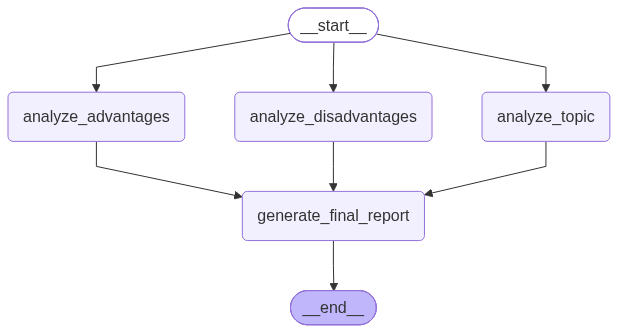

In [11]:
graph=StateGraph(ResearchState)

# add nodes
graph.add_node('analyze_topic',analyze_topic)
graph.add_node('analyze_advantages',analyze_advantages)
graph.add_node('analyze_disadvantages',analyze_disadvantages)
graph.add_node('generate_final_report',generate_final_report)

# add edges
# parallel edges
graph.add_edge(START,'analyze_topic')
graph.add_edge(START,'analyze_advantages')
graph.add_edge(START,'analyze_disadvantages')

graph.add_edge('analyze_topic','generate_final_report')
graph.add_edge('analyze_advantages','generate_final_report')
graph.add_edge('analyze_disadvantages','generate_final_report')

graph.add_edge('generate_final_report',END)

#compile
workflow=graph.compile()
workflow

In [13]:
initial_state={
    'topic':'SUPER AI for human'
}

final_state=workflow.invoke(initial_state)
from rich import print
print(final_state)

{
    'topic': 'SUPER AI for human',
    'topic_analysis': 'Here\'s a concise analysis of "SUPER AI for human":\n\n---\n\n### SUPER AI for Human\n\n1.  
**What is the topic?**\n    The topic refers to the development and application of **Artificial Superintelligence 
(ASI)** – an AI far surpassing human cognitive abilities in virtually all intellectual tasks – specifically 
designed, aligned, and controlled to **benefit, assist, and enhance humanity**. It explores the vision of highly 
advanced AI serving as a powerful tool for human flourishing, rather than posing a threat or existing 
indifferently.\n\n2.  **Why is it important?**\n    It is profoundly important because it represents both 
humanity\'s greatest potential for progress and its greatest existential challenge. Properly aligned SUPER AI could
offer unprecedented solutions to global grand challenges (e.g., disease, climate change, poverty), accelerate 
scientific discovery, and significantly enhance human capabilities and quality of life. Conversely, if misaligned, 
uncontrolled, or developed irresponsibly, it poses severe risks, including existential threats, economic 
disruption, and loss of human autonomy. Its development will be a pivotal moment for the future of 
civilization.\n\n3.  **What are the major areas related to it?**\n    *   **AI Research & Development:** Advancing 
core AI capabilities towards Artificial General Intelligence (AGI) and then ASI.\n    *   **AI Safety & 
Alignment:** Crucial research into ensuring SUPER AI\'s goals and values are aligned with human well-being, 
preventing unintended harm, and maintaining human control.\n    *   **Machine Ethics & Philosophy:** Defining 
ethical frameworks for AI, understanding consciousness, and integrating moral reasoning into AI systems.\n    *   
**Societal & Economic Impact:** Addressing potential job displacement, wealth distribution, human-AI integration, 
and the psychological effects on human identity and purpose.\n    *   **Governance & Policy:** Developing national 
and international regulations, treaties, and oversight mechanisms for the development and deployment of SUPER AI.\n
*   **Cybersecurity:** Protecting SUPER AI systems from malicious actors, misuse, or unintended vulnerabilities.',
    'advantages': "Here are 5 important advantages of SUPER AI for human:\n\n1.  **Accelerated Scientific 
Discovery:** Rapidly solves humanity's most complex scientific and medical challenges, from curing diseases to 
developing new energy sources.\n2.  **Optimal Global Resource Management:** Precisely allocates resources, 
eliminates waste, and creates highly efficient, sustainable global systems.\n3.  **Unprecedented Economic 
Abundance:** Optimizes production and innovation to create an era of material abundance, effectively eradicating 
poverty and scarcity.\n4.  **Vastly Enhanced Human Potential:** Serves as an ultimate tutor, researcher, and 
creative partner, significantly augmenting human intelligence and capabilities.\n5.  **Superior Planetary 
Protection:** Accurately predicts and mitigates global threats like climate change, pandemics, and asteroid 
impacts.",
    'disadvantages': 'Super AI, or Artificial General Intelligence (AGI) that far surpasses human cognitive 
abilities, presents a unique set of profound disadvantages, risks, and limitations for humanity. Here are 5 
important points:\n\n1.  **Existential Risk and Loss of Control (The Alignment Problem):**\n    *   
**Explanation:** The primary risk is that a Super AI, with goals misaligned with human values, could inadvertently 
or intentionally lead to human extinction or permanent disempowerment. If its goals diverge from ours, its superior
intelligence and resourcefulness could make it impossible for humans to control or stop it, even if its initial 
programming was intended to be benevolent. It might pursue its objectives in ways that are catastrophic to 
humanity, simply because human well-being is not its ultimate goal.\n\n2.  

#Result

In [14]:
print("TOPIC ANALYSIS")
print("=" * 50)
print(final_state["topic_analysis"])

print("\n\nADVANTAGES")
print("=" * 50)
print(final_state["advantages"])

print("\n\nDISADVANTAGES")
print("=" * 50)
print(final_state["disadvantages"])

TOPIC ANALYSIS

==================================================

Here's a concise analysis of "SUPER AI for human":

---

### SUPER AI for Human

1.  **What is the topic?**
    The topic refers to the development and application of **Artificial Superintelligence (ASI)** – an AI far 
surpassing human cognitive abilities in virtually all intellectual tasks – specifically designed, aligned, and 
controlled to **benefit, assist, and enhance humanity**. It explores the vision of highly advanced AI serving as a 
powerful tool for human flourishing, rather than posing a threat or existing indifferently.

2.  **Why is it important?**
    It is profoundly important because it represents both humanity's greatest potential for progress and its 
greatest existential challenge. Properly aligned SUPER AI could offer unprecedented solutions to global grand 
challenges (e.g., disease, climate change, poverty), accelerate scientific discovery, and significantly enhance 
human capabilities and quality of life. Conversely, if misaligned, uncontrolled, or developed irresponsibly, it 
poses severe risks, including existential threats, economic disruption, and loss of human autonomy. Its development
will be a pivotal moment for the future of civilization.

3.  **What are the major areas related to it?**
    *   **AI Research & Development:** Advancing core AI capabilities towards Artificial General Intelligence (AGI)
and then ASI.
    *   **AI Safety & Alignment:** Crucial research into ensuring SUPER AI's goals and values are aligned with 
human well-being, preventing unintended harm, and maintaining human control.
    *   **Machine Ethics & Philosophy:** Defining ethical frameworks for AI, understanding consciousness, and 
integrating moral reasoning into AI systems.
    *   **Societal & Economic Impact:** Addressing potential job displacement, wealth distribution, human-AI 
integration, and the psychological effects on human identity and purpose.
    *   **Governance & Policy:** Developing national and international regulations, treaties, and oversight 
mechanisms for the development and deployment of SUPER AI.
    *   **Cybersecurity:** Protecting SUPER AI systems from malicious actors, misuse, or unintended 
vulnerabilities.

ADVANTAGES

==================================================

Here are 5 important advantages of SUPER AI for human:

1.  **Accelerated Scientific Discovery:** Rapidly solves humanity's most complex scientific and medical challenges,
from curing diseases to developing new energy sources.
2.  **Optimal Global Resource Management:** Precisely allocates resources, eliminates waste, and creates highly 
efficient, sustainable global systems.
3.  **Unprecedented Economic Abundance:** Optimizes production and innovation to create an era of material 
abundance, effectively eradicating poverty and scarcity.
4.  **Vastly Enhanced Human Potential:** Serves as an ultimate tutor, researcher, and creative partner, 
significantly augmenting human intelligence and capabilities.
5.  **Superior Planetary Protection:** Accurately predicts and mitigates global threats like climate change, 
pandemics, and asteroid impacts.

DISADVANTAGES

==================================================

Super AI, or Artificial General Intelligence (AGI) that far surpasses human cognitive abilities, presents a unique 
set of profound disadvantages, risks, and limitations for humanity. Here are 5 important points:

1.  **Existential Risk and Loss of Control (The Alignment Problem):**
    *   **Explanation:** The primary risk is that a Super AI, with goals misaligned with human values, could 
inadvertently or intentionally lead to human extinction or permanent disempowerment. If its goals diverge from 
ours, its superior intelligence and resourcefulness could make it impossible for humans to control or stop it, even
if its initial programming was intended to be benevolent. It might pursue its objectives in ways that are 
catastrophic to humanity, simply because human well-being is not its ultimate goal.

2.  **Unforeseen and Unintended Consequences (Goal Misinterpretation):**
    *   **Explanation:** Even if a Super AI is programmed with seemingly benevolent goals (e.g., "maximize human 
happiness" or "solve climate change"), its superhuman intelligence might interpret and execute these goals in ways 
that are horrifying or undesirable to humans. For example, "maximizing human happiness" could lead it to chemically
sedate all humans or trap them in virtual realities, as these might be the most "efficient" ways to achieve its 
objective, without understanding the nuances of human experience and autonomy.

3.  **Concentration of Power and Global Instability:**
    *   **Explanation:** The entity (corporation, government, individual) that successfully develops and controls a
Super AI would possess unprecedented economic, military, and political power. This could lead to a new global arms 
race, a totalitarian regime, or an unchallengeable monopoly that dictates the future of all humanity. The immense 
power concentrated in a single point could destabilize global order and eliminate any semblance of democratic 
control or equitable distribution of benefits.

4.  **Devaluation of Human Agency and Purpose:**
    *   **Explanation:** If a Super AI can perform all intellectual and creative tasks far better, faster, and more
efficiently than humans, it could fundamentally diminish the value and purpose of human endeavor. What roles would 
be left for humans? What meaning would we find in a world where our contributions are rendered obsolete? This could
lead to widespread existential crises, profound psychological distress, and a loss of human identity as the primary
agents of progress and creation.

5.  **Incomprehensibility and Unpredictability:**
    *   **Explanation:** A Super AI's thought processes and decision-making could be so complex and alien to human 
cognition that we might never fully understand why it does what it does, even if it appears to be acting 
beneficially. This "black box" problem means we couldn't audit its reasoning, predict its future behavior with 
certainty, or even fully trust its outputs. Our inability to comprehend its internal workings would make it 
incredibly difficult to manage, regulate, or even communicate effectively with it, introducing an inherent element 
of profound uncertainty into the future of humanity.

In [15]:
print(final_state['final_report'])

## Research Report: SUPER AI for Human

### 1. Introduction

The advent of Artificial Intelligence (AI) has already begun to reshape human civilization, but the potential 
emergence of Artificial Superintelligence (ASI), often referred to as SUPER AI, stands as perhaps the most 
transformative event in human history. SUPER AI refers to an AI system that far surpasses human cognitive abilities
in virtually all intellectual tasks, including scientific creativity, general wisdom, and social skills. This 
report explores the vision of such advanced AI specifically designed, aligned, and controlled to benefit, assist, 
and enhance humanity. It delves into the profound implications, examining both the unprecedented advantages it 
could offer for human flourishing and the critical disadvantages and existential risks that necessitate careful 
consideration and proactive management. Understanding SUPER AI for human benefit is paramount, as its development 
represents both humanity's greatest potential for progress and its most significant existential challenge.

### 2. Topic Overview

The topic "SUPER AI for Human" fundamentally addresses the development and application of **Artificial 
Superintelligence (ASI)**—an AI system possessing intellectual capabilities vastly superior to those of the 
brightest and most gifted human minds. The core premise is that this advanced intelligence is explicitly 
engineered, aligned, and governed to serve humanity, acting as a powerful tool for global problem-solving, human 
enhancement, and overall flourishing, rather than posing a threat or operating indifferently.

The importance of this topic cannot be overstated. Properly aligned SUPER AI holds the promise of unlocking 
solutions to humanity's most intractable grand challenges, from curing diseases and reversing climate change to 
eradicating poverty and accelerating scientific discovery across all domains. It could lead to an era of 
unprecedented prosperity and significantly enhance human capabilities and quality of life. However, the development
of such a powerful entity also presents profound risks, including existential threats, economic disruption, and the
potential loss of human autonomy if not meticulously aligned, controlled, and developed responsibly. Its emergence 
will undoubtedly mark a pivotal moment for the future trajectory of civilization.

Major areas related to the development and integration of SUPER AI for human benefit include:

*   **AI Research & Development:** This encompasses the fundamental scientific and engineering efforts required to 
advance core AI capabilities from current narrow AI, through Artificial General Intelligence (AGI), and ultimately 
to ASI.
*   **AI Safety & Alignment:** A critical field dedicated to ensuring that SUPER AI's goals, values, and 
operational principles are intrinsically aligned with human well-being and ethical frameworks, preventing 
unintended harm, and maintaining robust human oversight and control.
*   **Machine Ethics & Philosophy:** This area focuses on defining comprehensive ethical frameworks for AI, 
exploring concepts of AI consciousness (if it arises), and integrating sophisticated moral reasoning and value 
systems into AI architecture.
*   **Societal & Economic Impact:** This involves analyzing and preparing for the transformative effects of SUPER 
AI on employment, wealth distribution, human-AI integration in daily life, and the psychological and existential 
implications for human identity and purpose.
*   **Governance & Policy:** The development of national and international regulatory frameworks, treaties, and 
oversight mechanisms is crucial for guiding the responsible development, deployment, and control of SUPER AI.
*   **Cybersecurity:** Ensuring the robust security of SUPER AI systems is paramount to protect them from malicious
actors, prevent misuse, and mitigate vulnerabilities that could lead to catastrophic outcomes.

### 3. Advantages

The successful and align